<a href="https://colab.research.google.com/github/ViniciusBarr0s/challenge.alura/blob/main/challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [6]:
loja["Loja"] = "Loja 1"
loja2["Loja"] = "Loja 2"
loja3["Loja"] = "Loja 3"
loja4["Loja"] = "Loja 4"


In [7]:
dados_lojas = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)
faturamento_lojas = dados_lojas.groupby("Loja")["Preço"].sum()

print(faturamento_lojas)



Loja
Loja 1    1534509.12
Loja 2    1488459.06
Loja 3    1464025.03
Loja 4    1384497.58
Name: Preço, dtype: float64


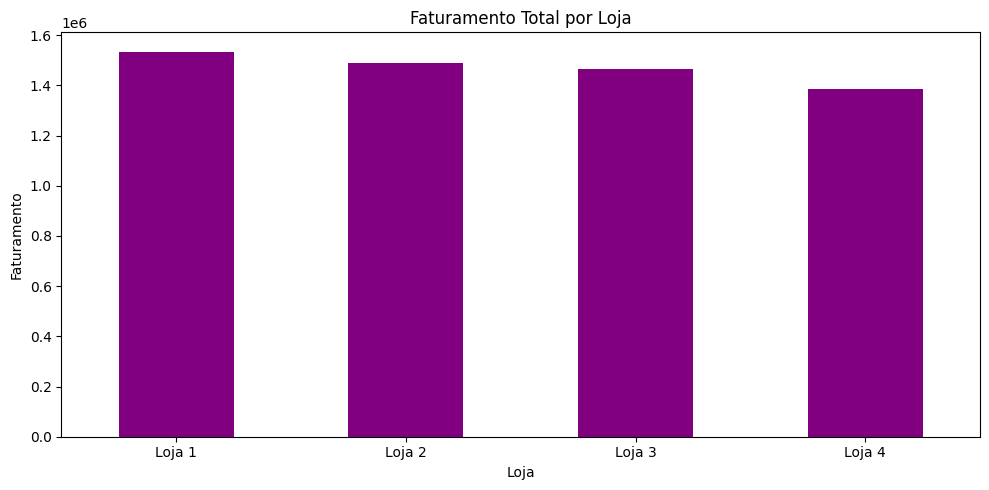

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

faturamento_lojas.plot(
    kind="bar",
    color="purple"
)

plt.title("Faturamento Total por Loja")
plt.xlabel("Loja")
plt.ylabel("Faturamento")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# 2. Vendas por Categoria

In [9]:
tabela_vendas_categoria = (
    dados_lojas
    .pivot_table(
        values="Preço",
        index="Loja",
        columns="Categoria do Produto",
        aggfunc="sum"
    )
    .round(2)
)

tabela_vendas_categoria


Categoria do Produto,brinquedos,eletrodomesticos,eletronicos,esporte e lazer,instrumentos musicais,livros,moveis,utilidades domesticas
Loja,,,,,,,,
Loja 1,23993.78,484913.36,572659.23,52387.55,121731.69,11713.92,250178.11,16931.48
Loja 2,21262.21,464758.13,547773.71,46326.09,139987.03,13454.35,235234.68,19662.86
Loja 3,25869.20,438984.89,547699.92,47456.10,103174.45,12664.70,268095.56,20080.21
Loja 4,27015.67,377680.65,545966.86,44465.65,100136.50,12427.77,256705.65,20098.83


<Figure size 1200x600 with 0 Axes>

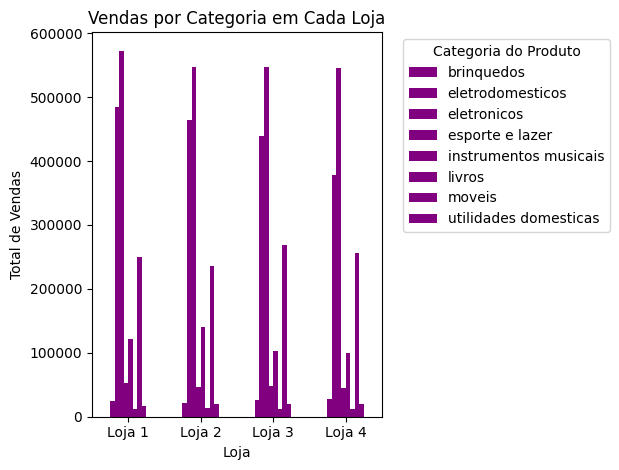

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,6))

tabela_vendas_categoria.plot(
    kind="bar",
    color="purple"
)

plt.title("Vendas por Categoria em Cada Loja")
plt.xlabel("Loja")
plt.ylabel("Total de Vendas")
plt.xticks(rotation=0)

plt.legend(title="Categoria do Produto", bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()

# 3. Média de Avaliação das Lojas


In [24]:
media_avaliacao_lojas = dados_lojas.groupby("Loja")["Avaliação da compra"].mean()

print(media_avaliacao_lojas)


Loja
Loja 1    3.976685
Loja 2    4.037304
Loja 3    4.048326
Loja 4    3.995759
Name: Avaliação da compra, dtype: float64


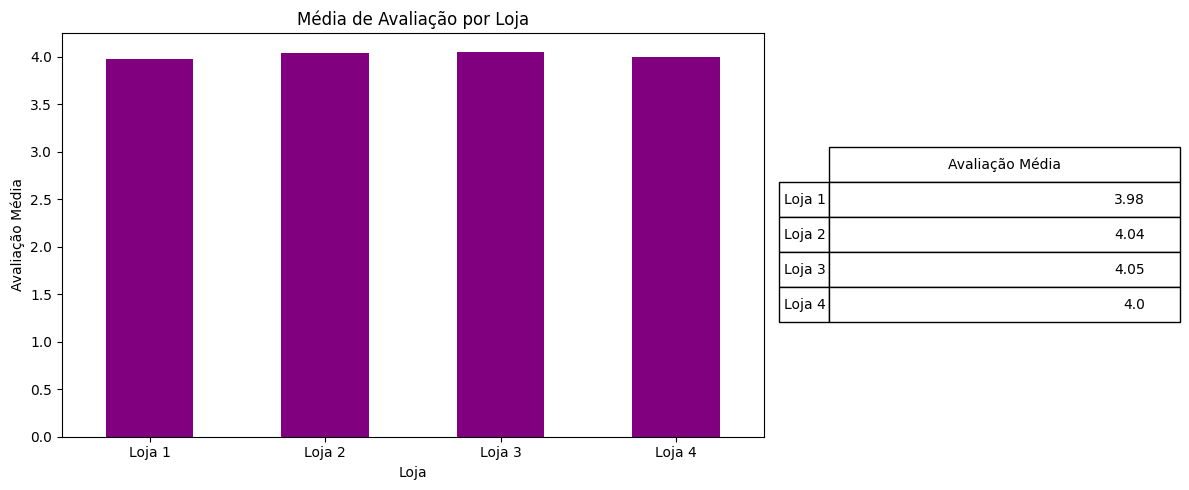

In [41]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


media_avaliacao_lojas = dados_lojas.groupby("Loja")["Avaliação da compra"].mean()


fig = plt.figure(figsize=(12,5))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])


ax_grafico = fig.add_subplot(gs[0])
media_avaliacao_lojas.plot(
    kind="bar",
    color="purple",
    ax=ax_grafico
)
ax_grafico.set_title("Média de Avaliação por Loja")
ax_grafico.set_xlabel("Loja")
ax_grafico.set_ylabel("Avaliação Média")
ax_grafico.set_xticklabels(media_avaliacao_lojas.index, rotation=0)


ax_tabela = fig.add_subplot(gs[1])
ax_tabela.axis("off")


tabela = ax_tabela.table(
    cellText=media_avaliacao_lojas.round(2).values.reshape(-1,1),
    rowLabels=media_avaliacao_lojas.index,
    colLabels=["Avaliação Média"],
    loc="center"
)
tabela.scale(1, 2)

plt.tight_layout()
plt.show()



# 4. Produtos Mais e Menos Vendidos

In [42]:
produtos_vendas = dados_lojas['Produto'].value_counts()


top3_produtos = produtos_vendas.head(3)
print("3 Produtos Mais Vendidos:")
print(top3_produtos)

3 Produtos Mais Vendidos:
Produto
Cômoda                      210
Carrinho controle remoto    206
Micro-ondas                 206
Name: count, dtype: int64


In [43]:
menos3_produtos = produtos_vendas.tail(3)
print("\n3 Produtos Menos Vendidos:")
print(menos3_produtos)


3 Produtos Menos Vendidos:
Produto
Mochila         163
Headset         158
Celular ABXY    157
Name: count, dtype: int64


# 5. Frete Médio por Loja

In [44]:
frete_medio_lojas = dados_lojas.groupby("Loja")["Frete"].mean().round(2)

print("Frete Médio por Loja:")
print(frete_medio_lojas)

Frete Médio por Loja:
Loja
Loja 1    34.69
Loja 2    33.62
Loja 3    33.07
Loja 4    31.28
Name: Frete, dtype: float64


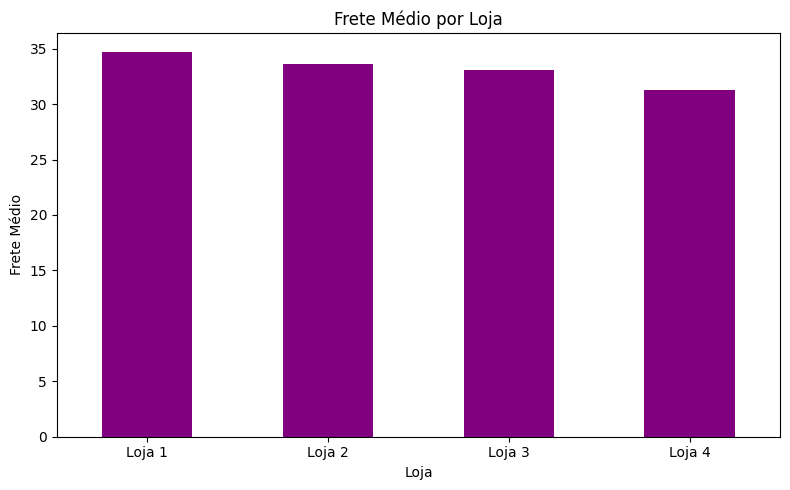

In [46]:
plt.figure(figsize=(8,5))

frete_medio_lojas.plot(
    kind="bar",
    color="purple"
)

plt.title("Frete Médio por Loja")
plt.xlabel("Loja")
plt.ylabel("Frete Médio")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Com isso vimos que a loja que mais compensa para o Sr.Joao utilizar para o investimento é a loja 4.